<a href="https://colab.research.google.com/github/laksamanaap/PCVK_Ganjil_2026/blob/main/P1/Tugas_Akuisisi_Citra_KTM_Modul_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Persiapan

File yang digunakan:
- `KTM1A.jpg` → ruangan gelap
- `KTM1B.jpg` → ruangan dengan lampu
- `KTM1C.jpg` → ruangan + flash
- `KTM1D.jpg` → luar ruangan / cahaya matahari

Pastikan file gambar berada di folder yang sama dengan notebook ini.

In [3]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Nama file dibuat satu tempat biar gampang kalau mau diganti
images = {
    "Dalam ruangan gelap": "KTM1A.jpg",
    "Dalam ruangan + lampu": "KTM1B.jpg",
    "Dalam ruangan + flash": "KTM1C.jpg",
    "Luar ruangan + matahari": "KTM1D.jpg"
}

# Cek dulu file-nya ada atau belum
for kondisi, nama_file in images.items():
    if not os.path.exists(nama_file):
        print(f"File belum ditemukan: {nama_file}")


## 2. Menampilkan hasil akuisisi

Keempat gambar dibandingkan dalam kondisi aslinya. Dari sini bisa dilihat pengaruh pencahayaan terhadap tingkat terang, bayangan, pantulan, dan detail KTM.

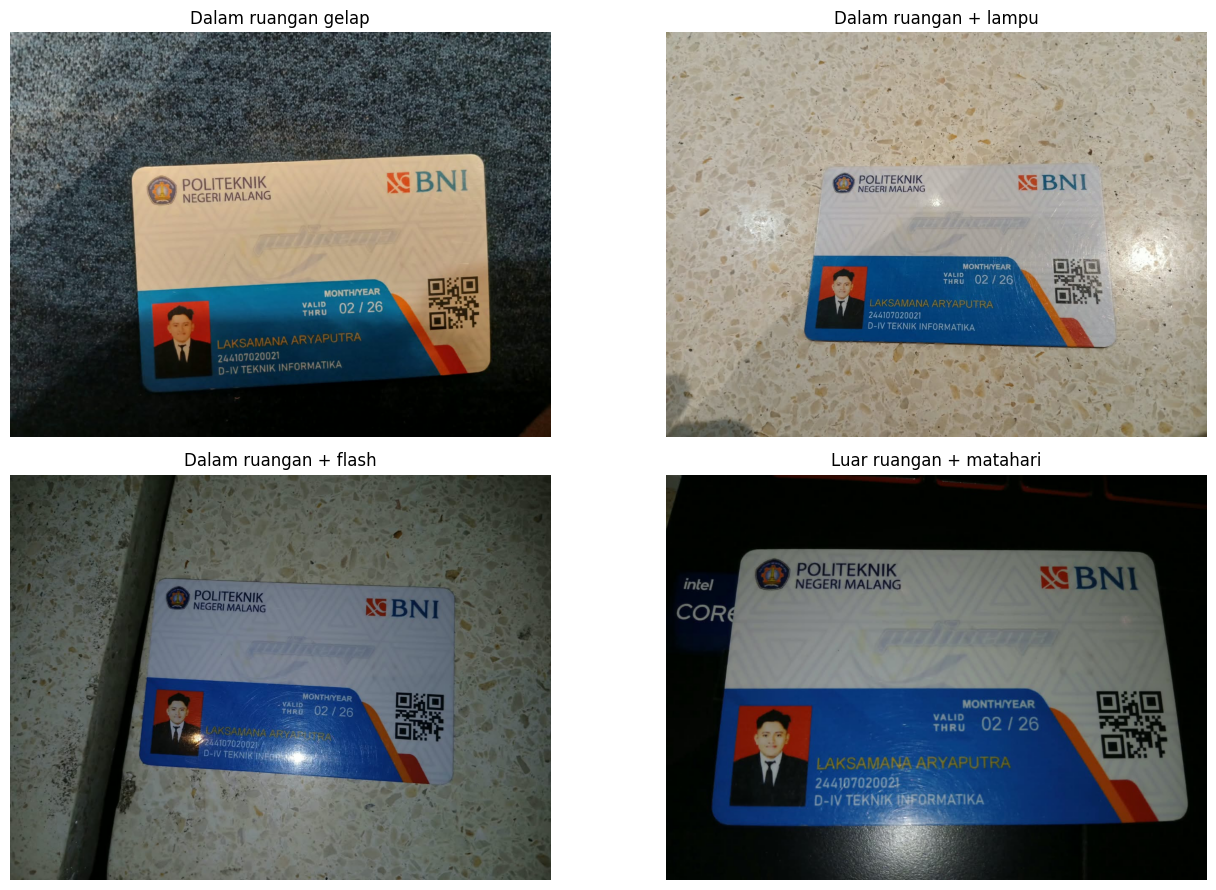

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (kondisi, nama_file) in zip(axes.ravel(), images.items()):
    img = Image.open(nama_file)
    ax.imshow(img)
    ax.set_title(kondisi)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Dimensi dan ukuran file

Dimensi citra menunjukkan ukuran gambar dalam piksel. Ukuran file menunjukkan banyaknya data yang disimpan pada file JPG.

Karena semua foto diambil dari kamera yang sama, dimensi gambar dapat tetap sama walaupun kondisi pencahayaannya berbeda. Ukuran file JPG belum tentu sama karena JPEG menggunakan kompresi sehingga isi/detail gambar ikut memengaruhi ukuran file.

In [5]:
data = []

for kondisi, nama_file in images.items():
    img = Image.open(nama_file).convert("RGB")
    arr = np.array(img)

    # Nilai grayscale dipakai hanya untuk melihat tingkat terang dan variasinya
    gray = np.dot(arr[..., :3], [0.299, 0.587, 0.114])

    file_size = os.path.getsize(nama_file)

    data.append({
        "Kondisi": kondisi,
        "File": nama_file,
        "Dimensi (pixel)": f"{img.width} x {img.height}",
        "Jumlah pixel": img.width * img.height,
        "Channel": arr.shape[2],
        "Ukuran file (KB)": round(file_size / 1024, 2),
        "Ukuran file (MB)": round(file_size / (1024**2), 3),
        "Rata-rata kecerahan": round(gray.mean(), 2),
        "Kontras (std)": round(gray.std(), 2)
    })

df = pd.DataFrame(data)
df


,Kondisi,File,Dimensi (pixel),Jumlah pixel,Channel,Ukuran file (KB),Ukuran file (MB),Rata-rata kecerahan,Kontras (std)
0,Dalam ruangan gelap,KTM1A.jpg,1280 x 960,1228800,3,130.74,0.128,78.53,59.14
1,Dalam ruangan + lampu,KTM1B.jpg,1280 x 960,1228800,3,119.50,0.117,155.09,37.34
2,Dalam ruangan + flash,KTM1C.jpg,1280 x 960,1228800,3,100.71,0.098,86.51,30.95
3,Luar ruangan + matahari,KTM1D.jpg,1280 x 960,1228800,3,61.49,0.060,55.90,52.62


## 4. Analisis perbedaan pencahayaan

**Dalam ruangan gelap:** pencahayaan yang sedikit membuat citra cenderung lebih gelap. Detail pada bagian tertentu KTM bisa lebih sulit terlihat dan noise lebih mudah muncul.

**Dalam ruangan dengan lampu:** pencahayaan lebih merata dibanding kondisi gelap. Tulisan dan bagian KTM lebih mudah terlihat, walaupun masih mungkin ada bayangan dari lingkungan sekitar.

**Dalam ruangan + flash:** flash membuat bagian KTM yang terkena cahaya menjadi lebih terang. Namun, pantulan pada permukaan kartu dapat menjadi lebih kuat sehingga beberapa bagian terlihat menyilaukan.

**Di luar ruangan dengan cahaya matahari:** pencahayaan alami memberikan detail yang cukup jelas, tetapi hasilnya tetap dipengaruhi posisi kartu terhadap sumber cahaya dan kondisi lingkungan. Bayangan atau area yang terlalu terang juga bisa muncul.

Secara umum, kondisi pencahayaan memengaruhi **kecerahan, kontras, detail, bayangan, dan pantulan** pada citra hasil akuisisi.

## 5. Crop citra KTM

Sesuai tugas lanjutan, citra dipotong sehingga bagian di luar KTM dihilangkan. Hasil crop disimpan sebagai:
- `KTM2A.jpg`
- `KTM2B.jpg`
- `KTM2C.jpg`
- `KTM2D.jpg`

Koordinat crop di bawah ini sudah disesuaikan dengan empat foto yang digunakan.

In [6]:
# Koordinat crop: (x1, y1, x2, y2)
crop_boxes = {
    "KTM1A.jpg": (325, 315, 1070, 760),
    "KTM1B.jpg": (275, 285, 1135, 855),
    "KTM1C.jpg": (100, 175, 1245, 850),
    "KTM1D.jpg": (335, 235, 1075, 740),
}

for nama_file, box in crop_boxes.items():
    img = Image.open(nama_file)
    hasil = img.crop(box)

    nama_hasil = nama_file.replace("KTM1", "KTM2")
    hasil.save(nama_hasil, quality=95)

    print(f"{nama_file} -> {nama_hasil} | {hasil.size[0]} x {hasil.size[1]} pixel")


KTM1A.jpg -> KTM2A.jpg | 745 x 445 pixel
KTM1B.jpg -> KTM2B.jpg | 860 x 570 pixel
KTM1C.jpg -> KTM2C.jpg | 1145 x 675 pixel
KTM1D.jpg -> KTM2D.jpg | 740 x 505 pixel


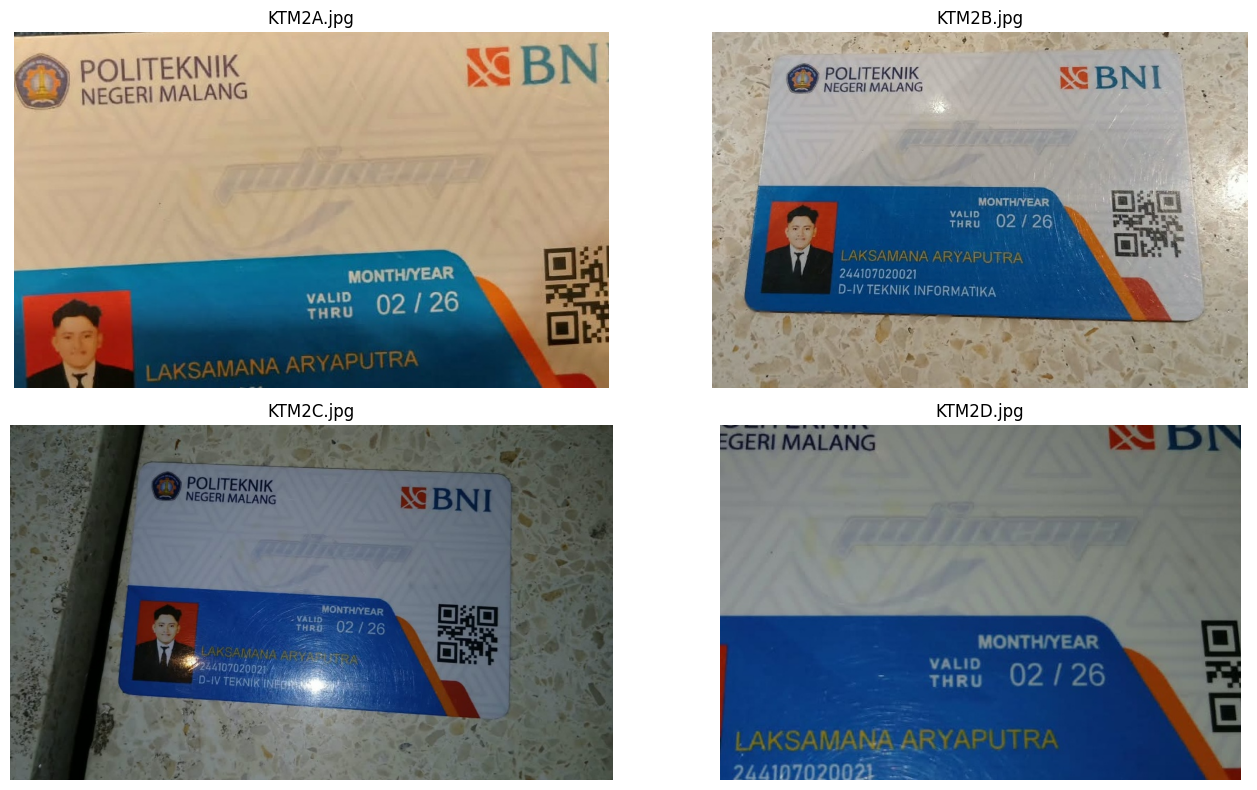

In [7]:
# Tampilkan hasil crop
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, nama_file in zip(axes.ravel(), crop_boxes.keys()):
    nama_hasil = nama_file.replace("KTM1", "KTM2")
    img = Image.open(nama_hasil)
    ax.imshow(img)
    ax.set_title(nama_hasil)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Membandingkan citra sebelum dan sesudah crop

Setelah crop, jumlah piksel menjadi lebih sedikit karena hanya bagian KTM yang dipertahankan. Ukuran file juga dapat berubah karena area gambar yang disimpan sudah berbeda.

Crop tidak mengubah isi KTM menjadi gambar baru dengan resolusi lebih tinggi; crop hanya mengambil sebagian area dari citra asli.

In [8]:
hasil_crop = []

for nama_file in crop_boxes:
    nama_hasil = nama_file.replace("KTM1", "KTM2")

    img1 = Image.open(nama_file)
    img2 = Image.open(nama_hasil)

    size1 = os.path.getsize(nama_file)
    size2 = os.path.getsize(nama_hasil)

    hasil_crop.append({
        "Kondisi": [k for k, v in images.items() if v == nama_file][0],
        "Citra awal": nama_file,
        "Dimensi awal": f"{img1.width} x {img1.height}",
        "Ukuran awal (KB)": round(size1 / 1024, 2),
        "Citra crop": nama_hasil,
        "Dimensi crop": f"{img2.width} x {img2.height}",
        "Ukuran crop (KB)": round(size2 / 1024, 2)
    })

df_crop = pd.DataFrame(hasil_crop)
df_crop


,Kondisi,Citra awal,Dimensi awal,Ukuran awal (KB),Citra crop,Dimensi crop,Ukuran crop (KB)
0,Dalam ruangan gelap,KTM1A.jpg,1280 x 960,130.74,KTM2A.jpg,745 x 445,78.67
1,Dalam ruangan + lampu,KTM1B.jpg,1280 x 960,119.50,KTM2B.jpg,860 x 570,160.78
2,Dalam ruangan + flash,KTM1C.jpg,1280 x 960,100.71,KTM2C.jpg,1145 x 675,215.12
3,Luar ruangan + matahari,KTM1D.jpg,1280 x 960,61.49,KTM2D.jpg,740 x 505,73.49
